In [1]:
!pip install Biopython

     |████████████████████████████████| 2.3MB 8.9MB/s 


In [3]:
import tarfile
import pandas as pd
import numpy as np
import re
from datetime import datetime

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Conv1D, MaxPooling1D

from matplotlib import pyplot as plt

from Bio.Seq import Seq

### Read data

In [4]:
filename = "training_data.tar.gz"

data = tarfile.open(filename, "r:gz")
data.extractall()
data.close()

In [5]:
b = open('ghl_gold.fa','r')
bind = b.readlines()
b.close()

u = open('ghl_gold_random.fa','r')
unbind = u.readlines()
u.close()

### Data preprocessing

In [6]:
bind = [v for v in bind if '>' not in v]
bind = [s.replace('\n', '') for s in bind]
bind = [x.upper() for x in bind]

unbind = [v for v in unbind if '>' not in v]
unbind = [s.replace('\n', '') for s in unbind]
unbind = [x.upper() for x in unbind]

In [ ]:
print(len(bind), len(unbind))

1400090 1400090


##### Reverse complement

In [7]:
bind_rev = list(range(len(bind)))

for i in range(len(bind)):
  seq = Seq(bind[i])
  rev = seq.reverse_complement()
  bind_rev[i] = str(rev)

unbind_rev = list(range(len(unbind)))

for i in range(len(unbind)):
  seq = Seq(unbind[i])
  rev = seq.reverse_complement()
  unbind_rev[i] = str(rev)

In [8]:
bind_fb = bind + bind_rev
unbind_fb = unbind + unbind_rev

In [9]:
bind_label = [1 for i in range(len(bind_fb))]
unbind_label = [0 for i in range(len(unbind_fb))]

In [10]:
bind_dict = {"seq":bind_fb, "label":bind_label}
unbind_dict = {"seq":unbind_fb, "label":unbind_label}

In [11]:
bind_df = pd.DataFrame(bind_dict)
unbind_df = pd.DataFrame(unbind_dict)

In [12]:
df = pd.concat([bind_df, unbind_df])

##### split the dataset

In [13]:
from sklearn.utils import shuffle

new_df = shuffle(df)
new_df = new_df.reset_index()

In [14]:
x = new_df.seq
y = new_df.label

In [15]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=40)

##### One-hot Encoding

In [16]:
LE = LabelEncoder()
LE.fit(['A', 'C', 'G', 'T', 'N'])

LabelEncoder()

In [17]:
start = datetime.now()

for index, row in x_train.items():
  x_train[index] = LE.transform(list(row))

for index, row in x_test.items():
  x_test[index] = LE.transform(list(row))

x_train = to_categorical(x_train.values.tolist())
x_test = to_categorical(x_test.values.tolist())

y_train = to_categorical(y_train.values.tolist())
y_t = to_categorical(y_test.values.tolist())

end = datetime.now()
print("encoding running time : "+str(end-start))

encoding running time : 0:05:38.469056


### CNN model

In [34]:
model=Sequential()
model.add(Conv1D(filters=64, kernel_size=7, strides=1, padding='valid', input_shape=(20,5), activation='relu'))
model.add(MaxPooling1D(pool_size=3, strides=1, padding='valid'))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(2, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [35]:
model.summary()

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv1d_4 (Conv1D)            (None, 14, 64)            2304      
_________________________________________________________________
max_pooling1d_4 (MaxPooling1 (None, 12, 64)            0         
_________________________________________________________________
flatten_4 (Flatten)          (None, 768)               0         
_________________________________________________________________
dense_7 (Dense)              (None, 32)                24608     
_________________________________________________________________
dropout_3 (Dropout)          (None, 32)                0         
_________________________________________________________________
dense_8 (Dense)              (None, 2)                 66        
Total params: 26,978
Trainable params: 26,978
Non-trainable params: 0
__________________________________________________

In [36]:
history = model.fit(x_train, y_train, epochs=10, validation_split = 0.2)

Epoch 1/10
112008/112008 [==============================] - 326s 3ms/step - loss: 0.3604 - accuracy: 0.8427 - val_loss: 0.3313 - val_accuracy: 0.8565
Epoch 2/10
112008/112008 [==============================] - 326s 3ms/step - loss: 0.3372 - accuracy: 0.8555 - val_loss: 0.3272 - val_accuracy: 0.8583
Epoch 3/10
112008/112008 [==============================] - 326s 3ms/step - loss: 0.3348 - accuracy: 0.8567 - val_loss: 0.3261 - val_accuracy: 0.8588
Epoch 4/10
112008/112008 [==============================] - 325s 3ms/step - loss: 0.3335 - accuracy: 0.8573 - val_loss: 0.3323 - val_accuracy: 0.8567
Epoch 5/10
112008/112008 [==============================] - 326s 3ms/step - loss: 0.3330 - accuracy: 0.8577 - val_loss: 0.3272 - val_accuracy: 0.8590
Epoch 6/10
112008/112008 [==============================] - 329s 3ms/step - loss: 0.3322 - accuracy: 0.8579 - val_loss: 0.3298 - val_accuracy: 0.8572
Epoch 7/10
112008/112008 [==============================] - 327s 3ms/step - loss: 0.3321 - accuracy:

##### Evaluation

Accuracy

In [37]:
score = model.evaluate(x_test, y_t, verbose=1)
print("score = " + str(round(score[1],2)))

35003/35003 [==============================] - 63s 2ms/step - loss: 0.3237 - accuracy: 0.8603
score = 0.86


loss-epoch curve

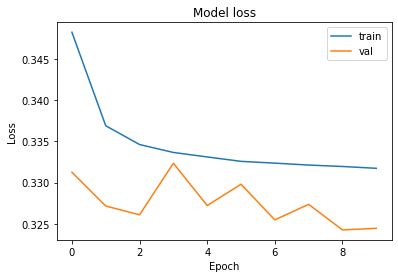

In [38]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

precision-recall curve

In [39]:
probs = model.predict(x_test, verbose=0)[:,1]

In [40]:
precision, recall, thresholds = precision_recall_curve(y_test.values, probs)

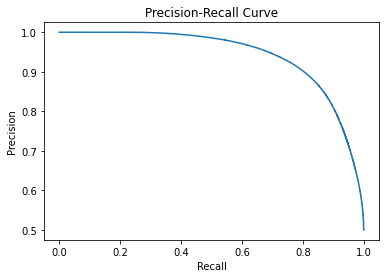

In [41]:
plt.plot(recall, precision)

plt.title('Precision-Recall Curve')

plt.xlabel('Recall')
plt.ylabel('Precision')

# plt.legend()
plt.show()

ROC curve & AUC

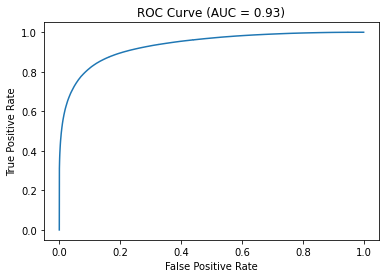

In [43]:
auc = roc_auc_score(y_test.values, probs)
fpr, tpr, _ = roc_curve(y_test.values, probs)

plt.plot(fpr, tpr)
plt.title('ROC Curve (AUC = ' + str(round(auc,2)) + ')')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()